# Premier League 2025/2026 Live Analytics Pipeline

## Scope and Objective

This notebook analyzes the live 2025/2026 Premier League season, where teams can have different numbers of matches played.

Data is refreshed automatically every Tuesday via GitHub Actions.

Goal: build a reliable match-level dataset, aggregate team metrics, and convert outputs into practical football and business insights.

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import kaleido
from adjustText import adjust_text
import plotly.graph_objects as go
import plotly.offline as pyo


pyo.init_notebook_mode(connected=True)

ASSETS_DIR = Path('assets/images')
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

## Data Ingestion

Load the source CSV into `df_raw` and inspect the first rows as a structural sanity check (columns, datatypes, missingness risk).

In [2]:
season = '2526'
league = 'E0'
url = f"https://www.football-data.co.uk/mmz4281/{season}/{league}.csv"
try:
    df_raw = pd.read_csv(url)
    display(df_raw.head())
except Exception as e:
    print(f"There was an error with downloading data: {e}")

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,1.95,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,1.98,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92


## Cleaning and Match Outcome Features

Keep rows complete for columns used downstream, then derive outcome features for modeling and flow analysis.

Created fields:
- `HomePoints` and `AwayPoints` from full-time score
- `HalfTimeResult` as the halftime match-state signal

In [3]:
df_clean = df_raw[['Date', 'HomeTeam', 'AwayTeam', 'HTHG', 'HTAG', 'FTHG',
'FTAG', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 
'AC', 'HY', 'AY', 'HR', 'AR']].copy()

df_clean.rename(columns={'FTHG': 'FullTimeHomeGoals', 'HTHG': 'HalfTimeHomeGoals',
'HTAG': 'HalfTimeAwayGoals', 'FTAG': 'FullTimeAwayGoals',
'HS': 'HomeShots', 'AS': 'AwayShots', 'HST': 'HomeShotsOnTarget',
'AST': 'AwayShotsOnTarget', 'HF': 'HomeFouls', 'AF': 'AwayFouls',
'HC': 'HomeCorners', 'AC': 'AwayCorners', 'HY': 'HomeYellowCards', 'AY': 'AwayYellowCards',
'HR': 'HomeRedCards', 'AR': 'AwayRedCards'}, inplace=True)

df_clean.dropna(subset=['FullTimeHomeGoals', 'HalfTimeHomeGoals', 'HalfTimeAwayGoals',
'FullTimeAwayGoals', 'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 
'HomeFouls', 'AwayFouls', 'HomeCorners', 'AwayCorners', 
'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards'], inplace=True)

conditions = [
    (df_clean['FullTimeHomeGoals'] > df_clean['FullTimeAwayGoals']),
    ((df_clean['FullTimeHomeGoals'] < df_clean['FullTimeAwayGoals'])),
    (df_clean['FullTimeHomeGoals'] == df_clean['FullTimeAwayGoals'])
]
choices = [3, 0, 1]
df_clean['HomePoints'] = np.select(conditions, choices)

choices2 = [0, 3, 1]
df_clean['AwayPoints'] = np.select(conditions, choices2)

conditions_half_time = [
    (df_clean['HalfTimeHomeGoals'] > df_clean['HalfTimeAwayGoals']),
    ((df_clean['HalfTimeHomeGoals'] < df_clean['HalfTimeAwayGoals'])),
    (df_clean['HalfTimeHomeGoals'] == df_clean['HalfTimeAwayGoals'])
]
choices_half_time = [1, -1, 0]
df_clean['HalfTimeResult'] = np.select(conditions_half_time, choices_half_time)

df_clean.head()

,Date,HomeTeam,AwayTeam,HalfTimeHomeGoals,HalfTimeAwayGoals,FullTimeHomeGoals,FullTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,...,AwayFouls,HomeCorners,AwayCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,HomePoints,AwayPoints,HalfTimeResult
0,15/08/2025,Liverpool,Bournemouth,1,0,4,2,19,10,10,...,10,6,7,1,2,0,0,3,0,1
1,16/08/2025,Aston Villa,Newcastle,0,0,0,0,3,16,3,...,11,3,6,1,1,1,0,1,1,0
2,16/08/2025,Brighton,Fulham,0,0,1,1,10,7,4,...,15,4,3,3,3,0,0,1,1,0
3,16/08/2025,Sunderland,West Ham,0,0,3,0,10,12,5,...,10,5,7,0,1,0,0,3,0,0
4,16/08/2025,Tottenham,Burnley,1,0,3,0,16,14,6,...,8,6,5,0,0,0,0,3,0,1


## Team Mapping and Table Logic

Map clubs to stable `TeamID`, reshape matches to team-centric records, and build standings.

Two ranking views are kept on purpose:
- `Position`: official table (Points, GoalDifference, GoalsFor)
- `PositionPPG`: fair live-season ranking for unequal games played

`Tier` is assigned from `PositionPPG` for comparability in ongoing-season analysis.

In [4]:
df_final = df_clean.copy()
teams = sorted(pd.unique(df_clean[['HomeTeam', 'AwayTeam']].to_numpy().ravel()))
df_teams = pd.DataFrame({'TeamID': range(len(teams)), 'TeamName': teams})
team_mapping = dict(zip(df_teams['TeamName'], df_teams['TeamID']))

df_final['HomeTeam'] = df_final['HomeTeam'].map(team_mapping)
df_final['AwayTeam'] = df_final['AwayTeam'].map(team_mapping)
df_final.rename(columns={'HomeTeam': 'HomeTeamID', 'AwayTeam': 'AwayTeamID'}, inplace=True)

df_final.head()

,Date,HomeTeamID,AwayTeamID,HalfTimeHomeGoals,HalfTimeAwayGoals,FullTimeHomeGoals,FullTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,...,AwayFouls,HomeCorners,AwayCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,HomePoints,AwayPoints,HalfTimeResult
0,15/08/2025,11,2,1,0,4,2,19,10,10,...,10,6,7,1,2,0,0,3,0,1
1,16/08/2025,1,14,0,0,0,0,3,16,3,...,11,3,6,1,1,1,0,1,1,0
2,16/08/2025,4,9,0,0,1,1,10,7,4,...,15,4,3,3,3,0,0,1,1,0
3,16/08/2025,16,18,0,0,3,0,10,12,5,...,10,5,7,0,1,0,0,3,0,0
4,16/08/2025,17,5,1,0,3,0,16,14,6,...,8,6,5,0,0,0,0,3,0,1


## Standings Aggregation

Convert match rows into season team totals by combining home and away contributions, then calculate both total and per-game metrics used by later analyses.

In [5]:
home_stats = df_final[['HomeTeamID', 'HomePoints', 'FullTimeHomeGoals', 'FullTimeAwayGoals']].copy()
home_stats.rename(columns={'HomeTeamID': 'TeamID', 'HomePoints': 'Points', 'FullTimeHomeGoals': 'GoalsFor',
'FullTimeAwayGoals': 'GoalsAgainst'}, inplace=True)
away_stats = df_final[['AwayTeamID', 'AwayPoints', 'FullTimeAwayGoals', 'FullTimeHomeGoals']].copy()
away_stats.rename(columns={'AwayTeamID': 'TeamID', 'AwayPoints': 'Points', 'FullTimeAwayGoals': 'GoalsFor',
'FullTimeHomeGoals': 'GoalsAgainst'}, inplace=True)

all_stats = pd.concat([home_stats, away_stats], ignore_index=True)

df_standings = (all_stats.groupby('TeamID', as_index=False).agg(Points=('Points', 'sum'),
GoalsFor=('GoalsFor', 'sum'), GoalsAgainst=('GoalsAgainst', 'sum'), Played=('TeamID', 'size')))

df_standings['GoalDifference'] = df_standings['GoalsFor'] - df_standings['GoalsAgainst']
df_standings['PointsPerGame'] = df_standings['Points'] / df_standings['Played']
df_standings['GoalDiffPerGame'] = df_standings['GoalDifference'] / df_standings['Played']
df_standings['GoalsForPerGame'] = df_standings['GoalsFor'] / df_standings['Played']

df_standings = df_standings.sort_values(by=['Points', 'GoalDifference', 'GoalsFor'],
ascending=[False, False, False]).reset_index(drop=True)
df_standings.insert(0, 'Position', range(1, len(df_standings) + 1), True)

ppg_rank = (df_standings[['TeamID', 'PointsPerGame',
'GoalDiffPerGame', 'GoalsForPerGame']].sort_values(by=['PointsPerGame',
'GoalDiffPerGame', 'GoalsForPerGame'],ascending=[False, False, False]).reset_index(drop=True)[['TeamID']])
ppg_rank['PositionPPG'] = range(1, len(ppg_rank) + 1)

df_standings = df_standings.merge(ppg_rank, on='TeamID', how='left')

bins = [0, 5, 10, 17, 20]
names = ['Top 5', 'Positions 6-10', 'Positions 11-17', 'Relegation zone']
df_standings['Tier'] = pd.cut(df_standings['PositionPPG'], bins=bins, labels=names)

df_standings = df_standings.sort_values('Position').reset_index(drop=True)
df_standings

,Position,TeamID,Points,GoalsFor,GoalsAgainst,Played,GoalDifference,PointsPerGame,GoalDiffPerGame,GoalsForPerGame,PositionPPG,Tier
0,1,0,70,63,26,33,37,2.121212,1.121212,1.909091,1,Top 5
1,2,12,67,65,29,32,36,2.093750,1.125000,2.031250,2,Top 5
2,3,13,58,58,45,33,13,1.757576,0.393939,1.757576,3,Top 5
3,4,1,58,47,41,33,6,1.757576,0.181818,1.424242,4,Top 5
4,5,11,55,54,43,33,11,1.666667,0.333333,1.636364,5,Top 5
5,6,6,48,53,42,33,11,1.454545,0.333333,1.606061,6,Positions 6-10
6,7,3,48,48,44,33,4,1.454545,0.121212,1.454545,7,Positions 6-10
7,8,2,48,50,50,33,0,1.454545,0.000000,1.515152,8,Positions 6-10
8,9,4,47,45,39,33,6,1.424242,0.181818,1.363636,9,Positions 6-10
9,10,8,47,40,39,33,1,1.424242,0.030303,1.212121,10,Positions 6-10


## SQLite Persistence

Persist `Matches`, `Teams`, and `Standings` to SQLite so all SQL-based EDA runs on a consistent and reproducible snapshot.

In [6]:
engine = create_engine('sqlite:///:memory:')
df_final.to_sql('Matches', con=engine, index=False, if_exists='replace')
df_teams.to_sql('Teams', con=engine, index=False, if_exists='replace')
df_standings.to_sql('Standings', con=engine, index=False, if_exists='replace')

20

## Offensive Profiling: Volume, Finishing, and Set-Piece Pressure

This chart combines three attacking indicators:
- `AvgShots`: chance volume per team-match
- `ConversionRate`: total goals divided by total shots
- `AvgCorners`: territorial pressure proxy

Because the season is live, per-match metrics are used to keep teams comparable despite unequal games played.

### So What?
- Teams above both reference lines pair shot volume with efficient finishing
- High volume but low conversion suggests shot quality or finishing issues
- Low volume but high conversion often indicates selective, transition-led attacks

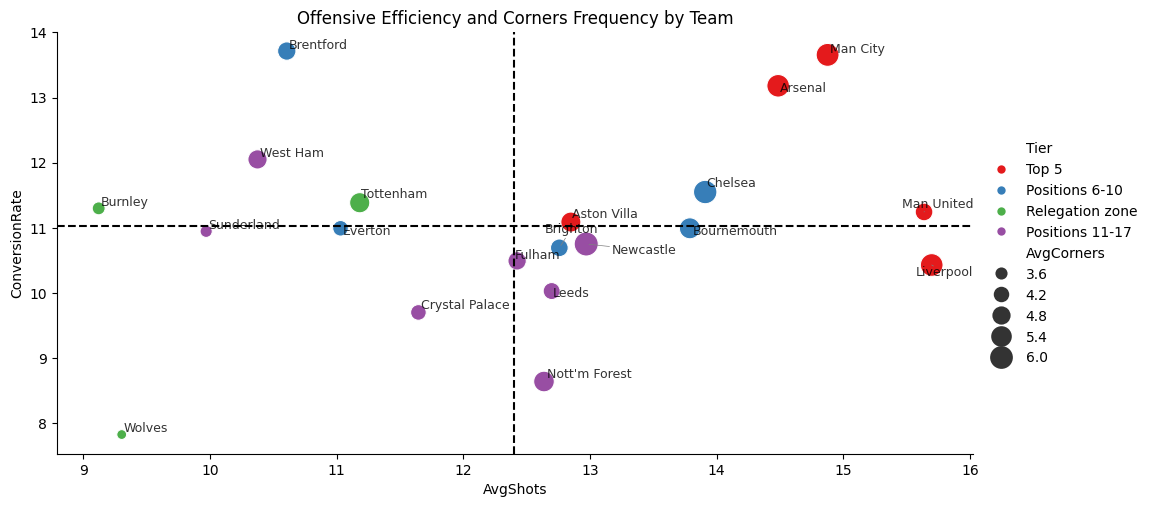

In [7]:
query_shots_corelation = """
with AllMatches as(
select HomeTeamID as TeamID, FullTimeHomeGoals AS Goals, HomeShots as Shots, HomeCorners as Corners
from Matches
union all
select AwayTeamID as TeamID, FullTimeAwayGoals AS Goals, AwayShots as Shots, AwayCorners as Corners
from Matches
)
select T.TeamName, S.Tier, avg(AM.Shots) as AvgShots,
sum(AM.Goals) * 100.0 / nullif(sum(AM.Shots),0) AS ConversionRate, avg(AM.Corners) as AvgCorners,
S.Played
from AllMatches AM
join Teams T on AM.TeamID=T.TeamID
join Standings S on AM.TeamID=S.TeamID
group by T.TeamName, S.Tier, S.Played;
"""

df_shots_corelation = pd.read_sql(query_shots_corelation, engine)

plot = sns.relplot(data=df_shots_corelation, x='AvgShots',
y='ConversionRate', hue='Tier',
size='AvgCorners', aspect=2, sizes=(50, 300), palette='Set1')

ref_df = df_shots_corelation.dropna(subset=['AvgShots', 'ConversionRate', 'Played'])
weighted_avg_shots = np.average(ref_df['AvgShots'], weights=ref_df['Played'])
weighted_avg_conversion = np.average(ref_df['ConversionRate'], weights=ref_df['Played'])

plt.axvline(x=weighted_avg_shots, color='black', linestyle='--')
plt.axhline(y=weighted_avg_conversion, color='black', linestyle='--')

texts = []
for i in range(df_shots_corelation.shape[0]):
    texts.append(plt.text(x=df_shots_corelation.AvgShots[i],
y=df_shots_corelation.ConversionRate[i], s=df_shots_corelation.TeamName[i],
fontsize=9, alpha=0.8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
plt.title("Offensive Efficiency and Corners Frequency by Team")
plt.savefig(ASSETS_DIR / 'offensive_profiling.png', dpi=200, bbox_inches='tight')
plt.show()

## Pythagorean Expectation: Expected vs Actual Points

This model estimates expected points (`xPts`) from goals for/against, then compares that estimate with actual points.

In this version, draw probability is team-specific and shrinked toward league average to reduce small-sample noise in a live season.

### So What?
- Positive `Luck`: points overperformance versus goal-based expectation
- Negative `Luck`: potential underperformance versus underlying process
- Useful for separating table position from true performance trend

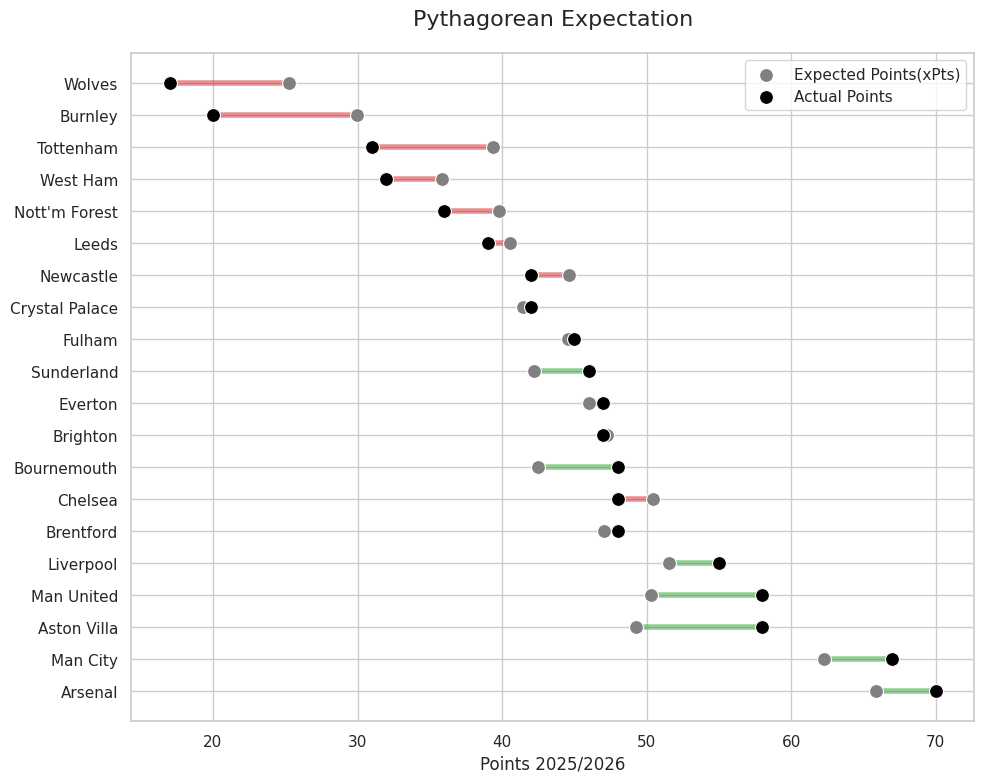

In [8]:
query_pythagorean = """
with AllMatches as (
select HomeTeamID as TeamID, case when FullTimeHomeGoals = FullTimeAwayGoals then 1 else 0 end as IsDraw
from Matches
union all
select AwayTeamID as TeamID, case when FullTimeHomeGoals = FullTimeAwayGoals then 1 else 0 end as IsDraw
from Matches
),
DrawsTeam as (
select TeamID, sum(IsDraw) as Draws
from AllMatches
group by TeamID
)
select T.TeamName, S.Played, S.Points as ActualPoints, S.GoalsFor,
S.GoalsAgainst, coalesce(DT.Draws, 0) as Draws
from Standings S
join Teams T on S.TeamID = T.TeamID
left join DrawsTeam DT on S.TeamID = DT.TeamID;
"""

df_pythagorean = pd.read_sql(query_pythagorean, engine)

exponent = 1.3
eps = 1e-9

gf = df_pythagorean['GoalsFor'].astype(float)
ga = df_pythagorean['GoalsAgainst'].astype(float)

p_non_draw_win = (gf + eps) ** exponent / ((gf + eps) ** exponent + (ga + eps) ** exponent)

df_matches = pd.read_sql(
    "select FullTimeHomeGoals, FullTimeAwayGoals from Matches",
    engine
)
draw_rate_league = (df_matches['FullTimeHomeGoals'] == df_matches['FullTimeAwayGoals']).mean()
k = 6
df_pythagorean['p_draw'] = (df_pythagorean['Draws'] + k * draw_rate_league) / (df_pythagorean['Played'] + k)

df_pythagorean['p_win'] = (1 - df_pythagorean['p_draw']) * p_non_draw_win
df_pythagorean['xPPG'] = 3 * df_pythagorean['p_win'] + 1 * df_pythagorean['p_draw']
df_pythagorean['xPts'] = df_pythagorean['Played'] * df_pythagorean['xPPG']
df_pythagorean['Luck'] = df_pythagorean['ActualPoints'] - df_pythagorean['xPts']

df_pythagorean = df_pythagorean.sort_values('ActualPoints', ascending=True).reset_index(drop=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

colors = ['#2ca02c' if luck > 0 else '#d62728' for luck in df_pythagorean['Luck']]
plt.hlines(y=df_pythagorean['TeamName'], xmin=df_pythagorean['xPts'], 
xmax=df_pythagorean['ActualPoints'], colors=colors, alpha=0.5, linewidth=4, zorder=1)

sns.scatterplot(data=df_pythagorean, x='xPts', y='TeamName', color='gray',
s=100, label='Expected Points(xPts)', zorder=3)
sns.scatterplot(data=df_pythagorean, x='ActualPoints', y='TeamName', color='black',
s=100, label='Actual Points', zorder=3)

plt.xlabel('Points 2025/2026', fontsize=12)
plt.ylabel('')
plt.title('Pythagorean Expectation', fontsize=16, pad=20)
plt.legend(loc='best')

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'pythagorean_expectation.png', dpi=200, bbox_inches='tight')
plt.show()

## Halftime to Fulltime Flow (Home Matches)

This Sankey aggregates league-wide transitions from halftime state to fulltime result in home matches.

State mapping:
- `HalfTimeResult`: 1 (home lead), 0 (draw), -1 (home trail)
- `HomePoints`: 3 (home win), 1 (draw), 0 (home loss)

### So What?
- `HT Draw` is usually the highest-volatility state
- `HT Lead` and `HT Trail` are relatively sticky
- For tactical coaching insights, replicate this flow at single-team level

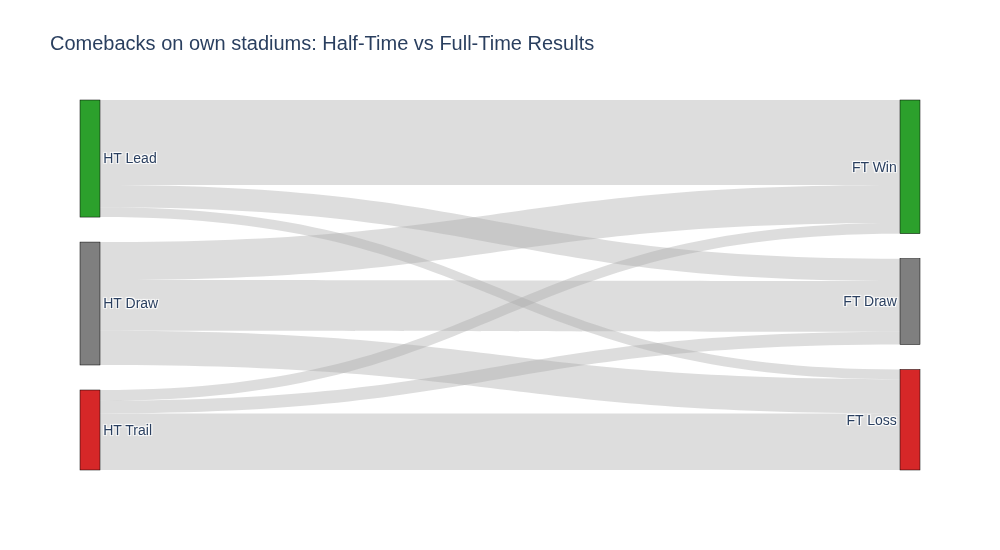

In [9]:
query_flows = """
select HalfTimeResult, HomePoints, count(*) as Number
from Matches
group by HalfTimeResult, HomePoints;
"""

df_flows = pd.read_sql(query_flows, engine)
ht_map = {1: 0, 0: 1, -1: 2}
ft_map = {3: 3, 1: 4, 0: 5}

df_flows['source'] = df_flows['HalfTimeResult'].map(ht_map)
df_flows['target'] = df_flows['HomePoints'].map(ft_map)

labels = ["HT Lead", "HT Draw", "HT Trail", "FT Win", "FT Draw", "FT Loss"]
colors = ["#2ca02c", "#7f7f7f", "#d62728", "#2ca02c", "#7f7f7f", "#d62728"]

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=25,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=labels,
        color=colors
    ),
    link=dict(
        source=df_flows['source'],
        target=df_flows['target'],
        value=df_flows['Number'],
        color="rgba(169, 169, 169, 0.4)"
    )
)])

fig.update_layout(
    title_text="Comebacks on own stadiums: Half-Time vs Full-Time Results",
    font_size=14,
    width=1000,
    height=550
)

try:
    fig.write_image(str(ASSETS_DIR / 'halftime_fulltime_flow.png'), scale=2)
    fig.show("png")
except Exception as e:
    fig.show()
    print(f"Static image export unavailable: {e}")

## Locker Room Impact: Second-Half Net Goal Differential

This metric isolates post-halftime performance by averaging each team’s net second-half goal difference per match.

SQL logic: compute net second-half differential from home and away perspectives, union both, then average by team.

### So What?
- Positive values indicate stronger halftime adaptation and game management
- Negative values may signal fitness drop-off, tactical rigidity, or bench-impact issues
- Useful for scouting coaching profile and in-game adjustment quality

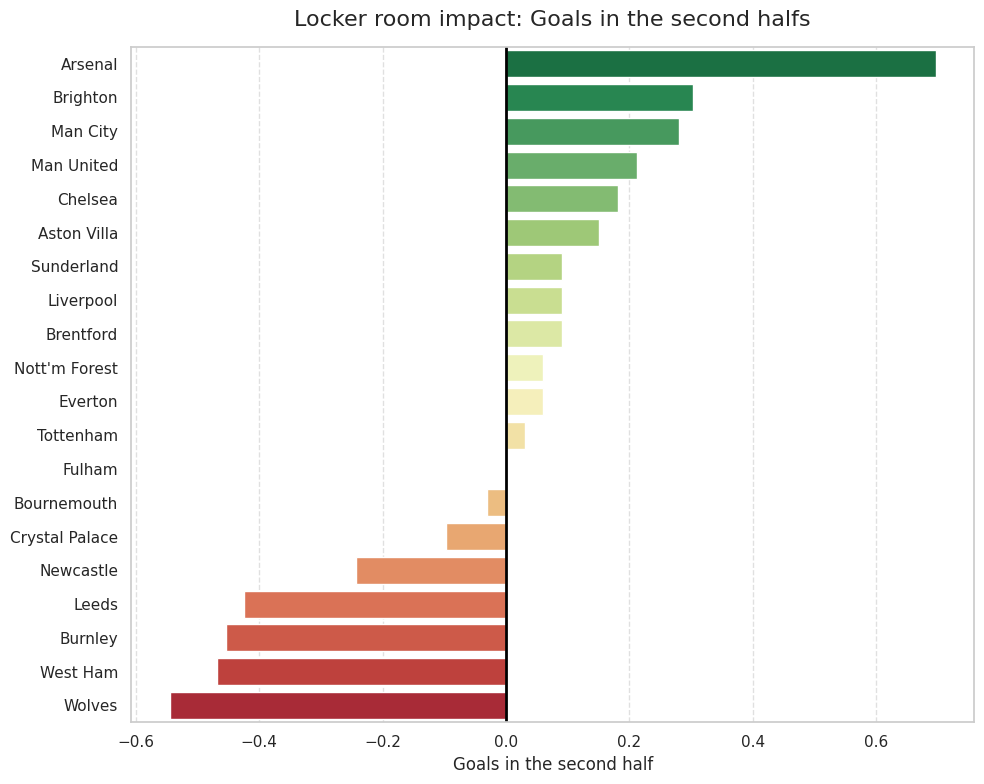

In [10]:
query_2nd_halfs = """
with SecondHalfs as (
select HomeTeamID as TeamID,
(FullTimeHomeGoals - HalfTimeHomeGoals) - (FullTimeAwayGoals - HalfTimeAwayGoals) as Net2ndHalfGoalDiff
from Matches
union all
select AwayTeamID as TeamID,
(FullTimeAwayGoals - HalfTimeAwayGoals) - (FullTimeHomeGoals - HalfTimeHomeGoals) as Net2ndHalfGoalDiff
from Matches
)
select T.TeamName, avg(SH.Net2ndHalfGoalDiff) as AvgNetGoals2ndHalf
from SecondHalfs SH
join Teams T on SH.TeamID = T.TeamID
group by T.TeamName
order by AvgNetGoals2ndHalf desc;
"""

df_2nd_half = pd.read_sql(query_2nd_halfs, engine)

plt.figure(figsize=(10, 8))
sns.barplot(data=df_2nd_half, x='AvgNetGoals2ndHalf', y='TeamName', palette='RdYlGn_r', hue='TeamName', legend=False)

plt.axvline(x=0, color='black', linewidth=2)

plt.title('Locker room impact: Goals in the second halfs', fontsize=16, pad=15)
plt.xlabel('Goals in the second half', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'locker_room_impact.png', dpi=200, bbox_inches='tight')
plt.show()